In [13]:
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [14]:
df = pd.read_csv("/Users/tylersun/Desktop/superconductor-ai/datasets/supercon2_v22.12.03.csv")
print("Initial dataset shape:", df.shape)


Initial dataset shape: (40324, 23)


In [15]:
def clean_tc(val):
    if isinstance(val, str):
        val = val.replace("K", "").strip()
        if "and" in val:
            nums = re.findall(r'\d+\.?\d*', val)
            nums = [float(n) for n in nums]
            return sum(nums) / len(nums)
        try:
            return float(val)
        except:
            return None
    return val

df['Tc'] = df['criticalTemperature'].apply(clean_tc)
df = df.dropna(subset=['Tc'])
print("Dataset shape after Tc cleaning:", df.shape)


Dataset shape after Tc cleaning: (36772, 24)


In [16]:
drop_cols = [
    'id', 'hash', 'title', 'doi', 'authors',
    'publisher', 'journal', 'section', 'subsection',
    'criticalTemperature'
]
df = df.drop(columns=drop_cols, errors='ignore')


In [17]:
target = 'Tc'
X = df.drop(columns=[target])
y = df[target]

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)


Numeric features: ['materialId', 'year']
Categorical features: ['rawMaterial', 'name', 'formula', 'doping', 'shape', 'materialClass', 'fabrication', 'substrate', 'variables', 'criticalTemperatureMeasurementMethod', 'appliedPressure']


In [18]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', max_categories=50))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)


In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)
print("Processed training set shape:", X_train_processed.shape)
print("Processed test set shape:", X_test_processed.shape)


Processed training set shape: (29417, 524)
Processed test set shape: (7355, 524)


In [20]:
def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print(f"\n{name} Results:")
    print(f"MSE: {mse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R²: {r2:.4f}")
    
    return {"Model": name, "MSE": mse, "MAE": mae, "R2": r2}

results = []

lr = LinearRegression()
results.append(evaluate_model("Linear Regression", lr, X_train_processed, y_train, X_test_processed, y_test))

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
results.append(evaluate_model("Random Forest", rf, X_train_processed, y_train, X_test_processed, y_test))

'''
from xgboost import XGBRegressor
xgb = XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=6, random_state=42, n_jobs=-1)
results.append(evaluate_model("XGBoost", xgb, X_train_processed, y_train, X_test_processed, y_test))
'''

results_df = pd.DataFrame(results)
print("\nSummary of Results:")
print(results_df)



Linear Regression Results:
MSE: 8288.6323
MAE: 30.8783
R²: 0.0350

Random Forest Results:
MSE: 11727.9988
MAE: 29.4750
R²: -0.3654

Summary of Results:
               Model           MSE        MAE        R2
0  Linear Regression   8288.632339  30.878343  0.035028
1      Random Forest  11727.998831  29.474983 -0.365388


In [21]:
print(X_train_processed.shape)
print(X_test_processed.shape)
print(y_train.shape)
print(y_test.shape)


(29417, 524)
(7355, 524)
(29417,)
(7355,)


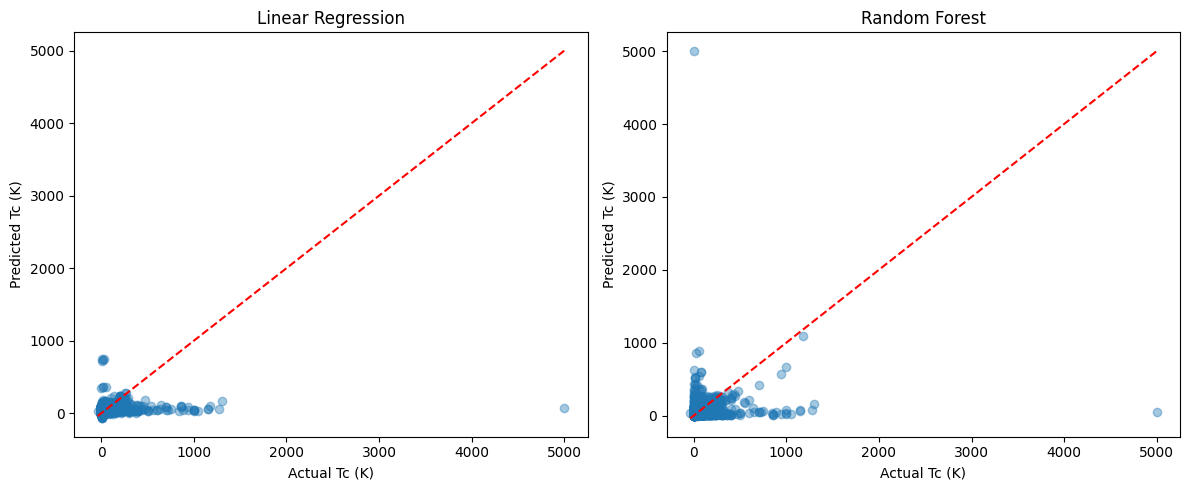

In [22]:
import matplotlib.pyplot as plt

# --- Plot predicted vs actual for each model ---
plt.figure(figsize=(12, 5))

for i, result in enumerate(results):
    name = result['Model']
    # Predict on test set
    if name == "Linear Regression":
        model = LinearRegression().fit(X_train_processed, y_train)
    elif name == "Random Forest":
        model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1).fit(X_train_processed, y_train)
    # Add XGBoost if available
    # elif name == "XGBoost":
    #     model = XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=6, random_state=42, n_jobs=-1).fit(X_train_processed, y_train)
    
    y_pred = model.predict(X_test_processed)
    
    plt.subplot(1, len(results), i+1)
    plt.scatter(y_test, y_pred, alpha=0.4)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.xlabel("Actual Tc (K)")
    plt.ylabel("Predicted Tc (K)")
    plt.title(f"{name}")

plt.tight_layout()
plt.show()


In [23]:
from sklearn.model_selection import RandomizedSearchCV
import matplotlib.pyplot as plt

# --- Hyperparameter tuning for Random Forest ---
param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 10, 20, 30, 50],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None]
}

rf = RandomForestRegressor(random_state=42, n_jobs=-1)

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,            # number of random combinations to try
    cv=3,                 # 3-fold cross validation
    verbose=1,
    n_jobs=-1,
    scoring="r2"          # optimize for R²
)

random_search.fit(X_train_processed, y_train)

print("\nBest Hyperparameters for Random Forest:")
print(random_search.best_params_)

# --- Evaluate tuned model ---


Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best Hyperparameters for Random Forest:
{'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 50}


In [24]:
# Get the best Random Forest model
best_rf = random_search.best_estimator_

# Predict on test set
y_pred_rf = best_rf.predict(X_test_processed)

# Compute metrics
mse = mean_squared_error(y_test, y_pred_rf)
mae = mean_absolute_error(y_test, y_pred_rf)
r2 = r2_score(y_test, y_pred_rf)

print("\nTuned Random Forest Results:")
print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")



Tuned Random Forest Results:
MSE: 7705.1598
MAE: 29.8503
R²: 0.1030


import matplotlib.pyplot as plt
import numpy as np

# Get feature importances
importances = best_rf.feature_importances_
# If you used a ColumnTransformer, extract feature names
try:
    feature_names = (numeric_features + 
                     list(preprocessor.named_transformers_['cat']['encoder'].get_feature_names_out(categorical_features)))
except:
    feature_names = numeric_features  # fallback if encoder info not available

# Sort top 20
indices = np.argsort(importances)[-20:]

plt.figure(figsize=(10, 6))
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), np.array(feature_names)[indices])
plt.xlabel("Importance")
plt.title("Top 20 Features Influencing Tc")
plt.show()


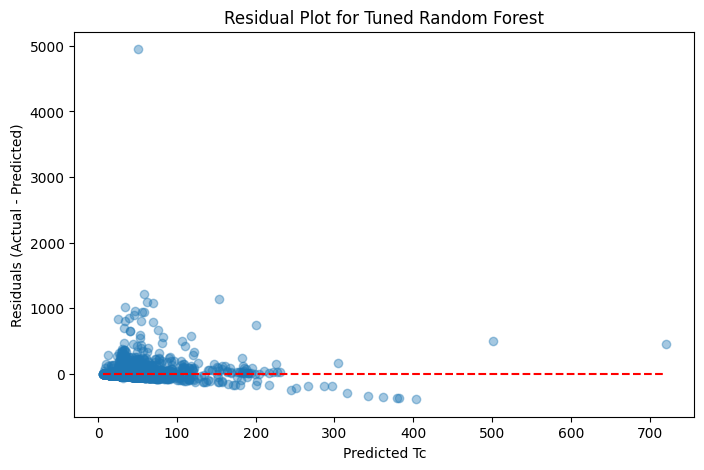

In [25]:
# Predict on test set
y_pred = best_rf.predict(X_test_processed)
residuals = y_test - y_pred

plt.figure(figsize=(8,5))
plt.scatter(y_pred, residuals, alpha=0.4)
plt.hlines(0, y_pred.min(), y_pred.max(), colors='r', linestyles='dashed')
plt.xlabel("Predicted Tc")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot for Tuned Random Forest")
plt.show()


In [30]:
# --- Create a template with all required columns ---
new_material = pd.DataFrame(columns=X_train.columns)

# Default values for numeric and categorical features
for col in numeric_features:
    new_material[col] = 0
for col in categorical_features:
    new_material[col] = "Unknown"

# Override example values for new material
new_material.loc[0, 'materialId'] = 99999
new_material.loc[0, 'year'] = 2025
new_material.loc[0, 'rawMaterial'] = 'ExampleMaterial'
new_material.loc[0, 'materialClass'] = 'ClassA'
new_material.loc[0, 'doping'] = 'Doped'
new_material.loc[0, 'shape'] = 'Powder'
# You can override/add more features here as needed

# --- Preprocess and predict ---
new_material_processed = preprocessor.transform(new_material)
predicted_tc = best_rf.predict(new_material_processed)

# --- Improved print with material info ---
material_name = new_material.loc[0, 'rawMaterial']
material_id = new_material.loc[0, 'materialId']
material_class = new_material.loc[0, 'materialClass']

print(f"Predicted Tc for material '{material_name}' (ID: {material_id}, Class: {material_class}): {predicted_tc[0]:.2f} K")


Predicted Tc for material 'ExampleMaterial' (ID: 99999.0, Class: ClassA): 34.52 K


In [29]:
# Create a new row as DataFrame
new_row = pd.DataFrame([{
    'Model': 'Tuned Random Forest',
    'MSE': mse,
    'MAE': mae,
    'R2': r2
}])

# Concatenate with existing results_df
results_df = pd.concat([results_df, new_row], ignore_index=True)

print("\nUpdated Summary of Results:")
print(results_df)



Updated Summary of Results:
                 Model           MSE        MAE        R2
0    Linear Regression   8288.632339  30.878343  0.035028
1        Random Forest  11727.998831  29.474983 -0.365388
2  Tuned Random Forest   7705.159804  29.850315  0.102956
